# Flight Fare Prediction Using Machine Learning

## Final-Year Engineering Project Notebook

This notebook presents a complete machine learning workflow for predicting flight fares. I have written it in a way that explains the reasoning behind each step, because in a real academic submission the examiner should be able to see not only the result, but also the thought process behind the system.

The project uses my existing production-level Python modules:

- `preprocess.py` for column standardisation, feature engineering, and pipeline creation
- `train.py` for reusable model training logic
- `utils.py` for price cleaning, metrics, prediction formatting, and live price simulation

The aim is to build a model that learns how flight price changes with airline, route, travel date, departure time, number of stops, duration, distance, and booking window.

## 1. Introduction

Flight ticket prices are highly dynamic. The fare for the same route can change depending on demand, airline, number of stops, departure time, season, route distance, and how early the ticket is booked.

In real life, airlines use dynamic pricing systems to adjust fares continuously. For example, a ticket booked close to the journey date may be more expensive because demand is urgent, while tickets booked earlier may be cheaper. Similarly, peak-hour flights, direct flights, and popular routes often have different pricing patterns.

The objective of this project is to use machine learning to estimate flight fares from historical flight data. This helps demonstrate how data-driven systems can support travel planning, fare comparison platforms, and airline revenue analysis.

## 2. Importing Required Libraries and Project Modules

In this section, I import standard data science libraries along with my own project modules. The important point is that the notebook does not rewrite the production logic. Instead, it uses the same reusable functions that are used by the application and training scripts.

In [25]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import KFold, cross_validate, train_test_split
from xgboost import XGBRegressor

import preprocess
import train
import utils

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

RANDOM_STATE = 42

## 3. Dataset Loading

The dataset is loaded using `pandas`. I first check whether the main CSV file is available, and then display the shape, columns, and initial records. This gives a basic understanding of the structure before any cleaning or modelling is done.

In [26]:
DATA_PATH = Path("Flight_Fare.xlsx")

if not DATA_PATH.exists():
    DATA_PATH = Path("flights.csv")

raw_df = pd.read_excel(DATA_PATH)

print(f"Dataset used: {DATA_PATH}")
print("Shape of dataset:", raw_df.shape)
print("\nColumns:")
print(raw_df.columns.tolist())

raw_df.head()

Dataset used: Flight_Fare.xlsx
Shape of dataset: (10683, 11)

Columns:
['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route', 'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops', 'Additional_Info', 'Price']


,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


### Basic Dataset Information

Before feature engineering, I inspect data types and missing values. This is important because machine learning models require clean numeric and categorical inputs, while real-world datasets often contain text, missing values, symbols, and inconsistent formats.

In [27]:
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Airline          10683 non-null  str  
 1   Date_of_Journey  10683 non-null  str  
 2   Source           10683 non-null  str  
 3   Destination      10683 non-null  str  
 4   Route            10682 non-null  str  
 5   Dep_Time         10683 non-null  str  
 6   Arrival_Time     10683 non-null  str  
 7   Duration         10683 non-null  str  
 8   Total_Stops      10682 non-null  str  
 9   Additional_Info  10683 non-null  str  
 10  Price            10683 non-null  int64
dtypes: int64(1), str(10)
memory usage: 1.8 MB


In [28]:
missing_summary = raw_df.isna().sum().sort_values(ascending=False)
missing_summary[missing_summary > 0]

Route          1
Total_Stops    1
dtype: int64

## 4. Data Cleaning

The target variable is flight fare. In many datasets, price values may contain symbols such as `?`, commas, spaces, or inconsistent text formatting. Even if the current dataset looks numeric, I still use the production cleaning function because a robust project should handle real-world input formats.

Here I use `utils.clean_price_column()` from my project instead of manually cleaning the price inside the notebook.

In [29]:
df_clean = utils.clean_price_column(raw_df)

print("Shape after price cleaning:", df_clean.shape)
df_clean.head()

Price column detected: 'Price'
Datatype after cleaning: int64
Null values after cleaning: 0
First 5 cleaned price values: [3897, 7662, 13882, 6218, 13302]
Shape after price cleaning: (10683, 11)


,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


After cleaning, I standardise the column names and infer the role of each column. This makes the pipeline flexible because it can work with datasets that use slightly different names, such as `Price`, `Fare`, `Dep_Time`, or `departure_time`.

In [30]:
df_standard = preprocess.standardize_columns(df_clean)
roles = preprocess.infer_roles(df_standard)

print("Inferred column roles:")
for role, column in roles.items():
    print(f"{role:18s} -> {column}")

Inferred column roles:
target             -> Price
date               -> Date_of_Journey
dep_time           -> Dep_Time
arrival_time       -> Arrival_Time
duration           -> Duration
stops              -> Total_Stops
airline            -> Airline
source             -> Source
destination        -> Destination
route              -> Route
additional_info    -> Additional_Info


## 5. Exploratory Data Analysis (EDA)

EDA helps me understand the behaviour of the target variable and its relationship with important features. I use visual analysis before modelling because it can reveal skewness, outliers, and patterns that the model later tries to learn.

### 5.1 Distribution of Flight Prices

This plot shows how flight fares are distributed. Flight prices are usually right-skewed because most tickets are in a normal range, while a smaller number of premium or last-minute tickets are much more expensive.

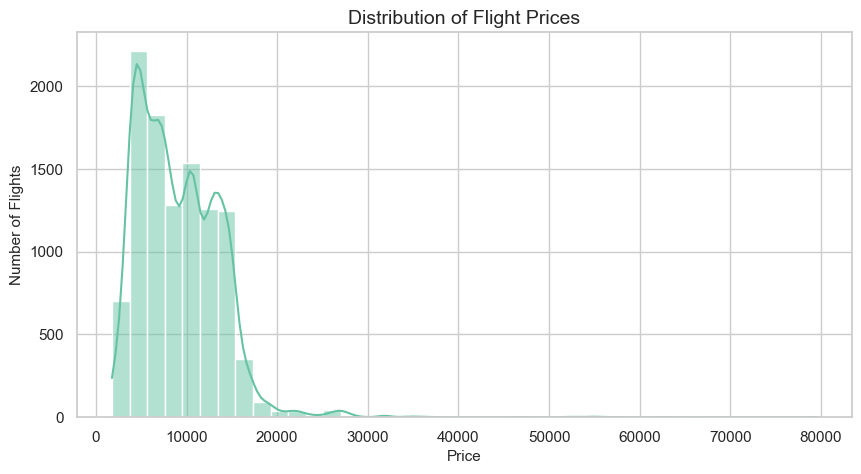

Insight: The distribution helps identify whether prices are concentrated in one range or spread across many fare levels.


In [31]:
price_col = roles["target"]

plt.figure(figsize=(10, 5))
sns.histplot(df_standard[price_col], bins=40, kde=True)
plt.title("Distribution of Flight Prices")
plt.xlabel("Price")
plt.ylabel("Number of Flights")
plt.show()

print("Insight: The distribution helps identify whether prices are concentrated in one range or spread across many fare levels.")

### 5.2 Airline vs Price

Different airlines follow different pricing strategies. Full-service carriers may charge more due to services, brand value, and route coverage, while low-cost carriers may generally offer cheaper fares.

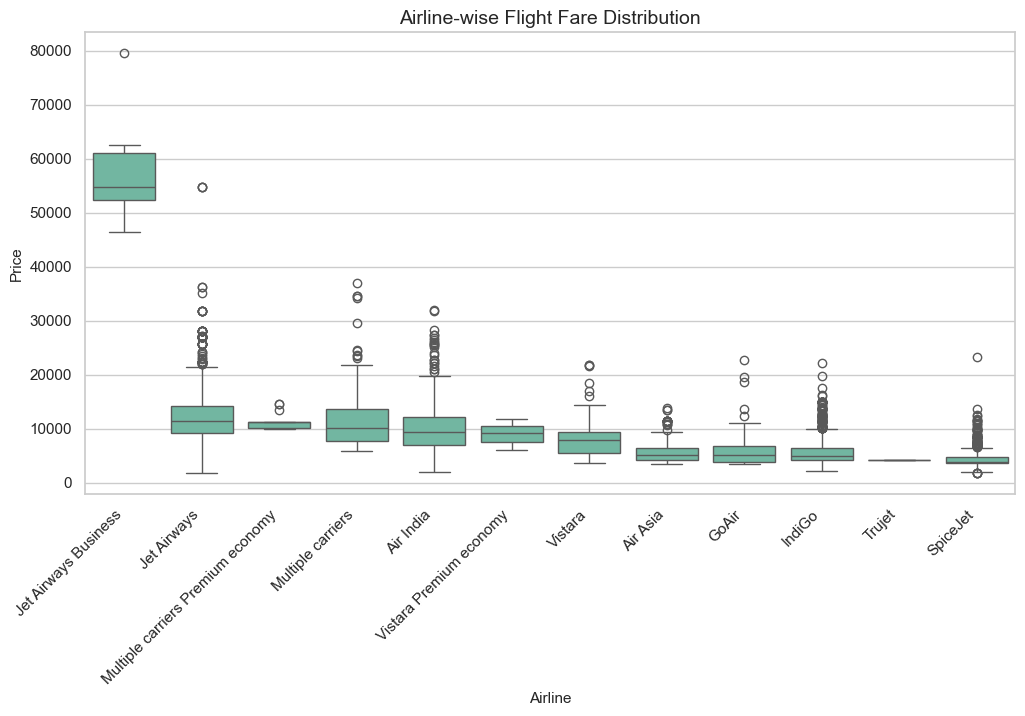

Insight: The median and spread show that airline brand is an important pricing signal.


In [32]:
airline_col = roles["airline"]

plt.figure(figsize=(12, 6))
order = df_standard.groupby(airline_col)[price_col].median().sort_values(ascending=False).index
sns.boxplot(data=df_standard, x=airline_col, y=price_col, order=order)
plt.title("Airline-wise Flight Fare Distribution")
plt.xlabel("Airline")
plt.ylabel("Price")
plt.xticks(rotation=45, ha="right")
plt.show()

print("Insight: The median and spread show that airline brand is an important pricing signal.")

### 5.3 Stops vs Price

The number of stops affects both convenience and operational cost. Non-stop flights are often preferred by passengers, while multi-stop routes may be cheaper or sometimes expensive due to route complexity.

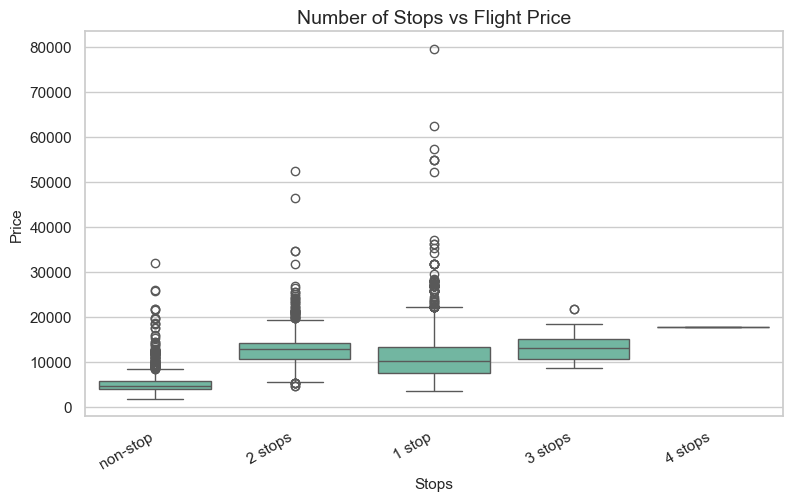

Insight: Stops influence fare because they affect travel time, passenger convenience, and route availability.


In [33]:
stops_col = roles["stops"]

plt.figure(figsize=(9, 5))
sns.boxplot(data=df_standard, x=stops_col, y=price_col)
plt.title("Number of Stops vs Flight Price")
plt.xlabel("Stops")
plt.ylabel("Price")
plt.xticks(rotation=30, ha="right")
plt.show()

print("Insight: Stops influence fare because they affect travel time, passenger convenience, and route availability.")

### 5.4 Duration vs Price

Duration is not always directly proportional to price, but it is still useful. Longer flights usually mean longer distance or more stops, both of which can influence fare.

To avoid duplicating feature logic, I use `preprocess.build_feature_dataframe()` and then visualise the engineered `Duration_minutes` feature created by the project module.

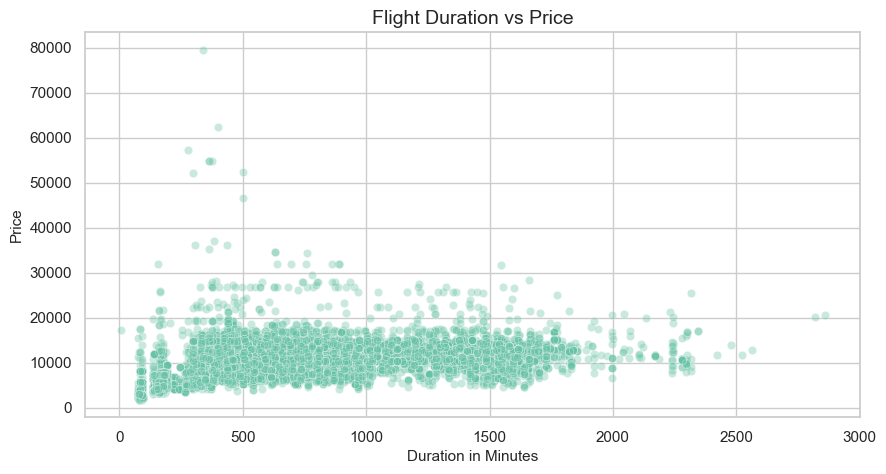

Insight: Duration provides useful information, especially when combined with route, stops, and distance.


In [34]:
X_preview, y_preview, metadata_preview = preprocess.build_feature_dataframe(df_standard, roles)

eda_duration = X_preview.copy()
eda_duration["Price"] = y_preview

plt.figure(figsize=(10, 5))
sns.scatterplot(data=eda_duration, x="Duration_minutes", y="Price", alpha=0.35)
plt.title("Flight Duration vs Price")
plt.xlabel("Duration in Minutes")
plt.ylabel("Price")
plt.show()

print("Insight: Duration provides useful information, especially when combined with route, stops, and distance.")

## 6. Feature Engineering

Feature engineering is one of the most important parts of this project. Raw flight data contains useful information, but much of it is hidden inside date strings, time strings, duration text, route text, and stop descriptions.

I use the following functions from `preprocess.py`:

- `standardize_columns()` to make column names consistent
- `infer_roles()` to detect which column represents airline, date, source, destination, duration, stops, and target price
- `build_feature_dataframe()` to create the final model-ready feature table

This keeps the notebook aligned with the production pipeline.

In [35]:
df_standard = preprocess.standardize_columns(df_clean)
roles = preprocess.infer_roles(df_standard)
X, y, metadata = preprocess.build_feature_dataframe(df_standard, roles)

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("\nFirst 10 engineered feature columns:")
print(metadata["feature_columns"][:10])

X.head()

Feature matrix shape: (10683, 34)
Target shape: (10683,)

First 10 engineered feature columns:
['Airline', 'Source', 'Destination', 'Source_Destination', 'Route', 'Additional_Info', 'Journey_day', 'Journey_month', 'Journey_year', 'Journey_quarter']


,Airline,Source,Destination,Source_Destination,Route,Additional_Info,Journey_day,Journey_month,Journey_year,Journey_quarter,...,Is_Night_Dep,Route_segments,Route_length,Route_stops_inferred,Has_stops_mismatch,Is_one_stop,Is_nonstop,Is_multicity,days_left,trend_factor
0,IndiGo,Banglore,New Delhi,Banglore_New Delhi,BLR->>DEL,No info,24,3,2019,1,...,1,2,2,1,1,0,1,0,0,1.0
1,Air India,Kolkata,Banglore,Kolkata_Banglore,CCU->>IXR->>BBI->>BLR,No info,1,5,2019,2,...,0,4,4,3,1,0,0,1,0,1.0
2,Jet Airways,Delhi,Cochin,Delhi_Cochin,DEL->>LKO->>BOM->>COK,No info,9,6,2019,2,...,0,4,4,3,1,0,0,1,0,1.0
3,IndiGo,Kolkata,Banglore,Kolkata_Banglore,CCU->>NAG->>BLR,No info,12,5,2019,2,...,0,3,3,2,1,1,0,0,0,1.0
4,IndiGo,Banglore,New Delhi,Banglore_New Delhi,BLR->>NAG->>DEL,No info,1,3,2019,1,...,0,3,3,2,1,1,0,0,0,1.0


### Explanation of Important Engineered Features

The features below are important because they convert raw text-based flight information into signals that a machine learning model can understand:

- **Date features:** Journey month, weekday, quarter, and week help capture seasonality and weekly travel demand.
- **Time features:** Departure hour and peak-hour indicators help identify flights during high-demand travel periods.
- **Duration in minutes:** Converts text such as `2h 50m` into a numeric travel-time feature.
- **Stops encoding:** Converts values such as `non-stop`, `1 stop`, and `2 stops` into numeric and binary features.
- **Distance:** Uses the Haversine formula to estimate geographic distance between source and destination cities.
- **days_left:** Represents the booking window, which is important because last-minute bookings are often costly.
- **trend_factor:** Represents year-based fare trend movement, allowing the model to account for price changes over time.
- **Route features:** Route segment count and route length help represent route complexity.

These features matter because flight fare is not decided by one factor alone. It is a combination of route, demand, convenience, timing, distance, and airline strategy.

In [36]:
important_features = [
    "Journey_month", "Journey_weekday", "Dep_hour", "Is_Peak_Hour",
    "Duration_minutes", "Total_Stops", "Distance_km", "days_left",
    "trend_factor", "Route_segments", "Is_nonstop", "Is_multicity"
]

available_important_features = [col for col in important_features if col in X.columns]
X[available_important_features].head()

,Journey_month,Journey_weekday,Dep_hour,Is_Peak_Hour,Duration_minutes,Total_Stops,Distance_km,days_left,trend_factor,Route_segments,Is_nonstop,Is_multicity
0,3,6,22,0,170,0,1739.802102,0,1.0,2,1,0
1,5,2,5,0,445,2,1560.696623,0,1.0,4,0,1
2,6,6,9,1,1140,2,2079.743081,0,1.0,4,0,1
3,5,6,18,1,325,1,1560.696623,0,1.0,3,0,0
4,3,4,16,0,285,1,1739.802102,0,1.0,3,0,0


### Feature Metadata

The metadata tells the pipeline which columns are numeric and which are categorical. This is important because numeric and categorical features need different preprocessing methods.

In [37]:
print("Numeric features:")
print(metadata["numeric_features"])

print("\nLow-cardinality categorical features:")
print(metadata["categorical_low_cardinality"])

print("\nHigh-cardinality categorical features:")
print(metadata["categorical_high_cardinality"])

Numeric features:
['Journey_day', 'Journey_month', 'Journey_year', 'Journey_quarter', 'Journey_week', 'Dep_hour', 'Dep_minute', 'Duration_minutes', 'Total_Stops', 'Distance_km', 'Arrival_hour', 'Arrival_minute', 'Journey_weekday', 'Is_Weekend', 'Is_Peak_Hour', 'Is_Morning_Dep', 'Is_Afternoon_Dep', 'Is_Evening_Dep', 'Is_Night_Dep', 'Route_segments', 'Route_length', 'Route_stops_inferred', 'Has_stops_mismatch', 'Is_one_stop', 'Is_nonstop', 'Is_multicity', 'days_left', 'trend_factor']

Low-cardinality categorical features:
['Source', 'Destination', 'Source_Destination', 'Additional_Info']

High-cardinality categorical features:
['Airline', 'Route']


## 7. Pipeline Building

A machine learning pipeline combines preprocessing and modelling into one object. This is important because the same transformations used during training must also be used during prediction.

My `preprocess.build_training_pipeline()` function handles:

- **Missing value treatment** using imputers
- **Scaling** of numeric features using `StandardScaler`
- **One-hot encoding** for low-cardinality categorical columns
- **Ordinal encoding** for high-cardinality categorical columns
- **Model fitting** as the final pipeline step

Using a pipeline reduces the risk of training-serving mismatch and keeps the system production-ready.

In [38]:
def wrap_target_model(model):
    # Log-transforming fares keeps very high prices from dominating the fit.
    return TransformedTargetRegressor(
        regressor=model,
        func=np.log1p,
        inverse_func=np.expm1
    )

sample_pipeline = preprocess.build_training_pipeline(
    metadata,
    wrap_target_model(LinearRegression())
)

sample_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('low_card', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different t

## 8. Model Training

I train three models for comparison:

1. **Linear Regression** as a simple baseline model
2. **Random Forest** to capture non-linear relationships and feature interactions
3. **XGBoost** as a strong gradient boosting model for tabular prediction problems

The target value is log-transformed during training using `TransformedTargetRegressor`. This helps because flight prices are often skewed, and log transformation can make the learning problem more stable.

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

models = {
    "Linear Regression": wrap_target_model(LinearRegression()),
    "Random Forest": wrap_target_model(RandomForestRegressor(
        n_estimators=300,
        max_depth=20,
        min_samples_leaf=2,
        max_features="sqrt",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )),
    "XGBoost": wrap_target_model(XGBRegressor(
        random_state=RANDOM_STATE,
        n_estimators=700,
        learning_rate=0.03,
        max_depth=8,
        subsample=0.85,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        tree_method="hist",
        eval_metric="rmse",
        reg_alpha=1.5,
        reg_lambda=2.5,
        verbosity=0,
        n_jobs=-1
    ))
}

trained_models = {}
evaluation_rows = []

for model_name, model in models.items():
    pipeline = preprocess.build_training_pipeline(metadata, model)
    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)
    metrics = utils.calculate_regression_metrics(y_test, predictions)

    trained_models[model_name] = pipeline
    evaluation_rows.append({
        "Model": model_name,
        "R2": metrics["r2"],
        "MAE": metrics["mae"],
        "RMSE": metrics["rmse"]
    })

    print(f"{model_name} training completed.")

Linear Regression training completed.
Random Forest training completed.
XGBoost training completed.


## 9. Model Evaluation

The models are evaluated using three standard regression metrics:

- **R? Score:** Measures how much variance in price is explained by the model. Higher is better.
- **MAE:** Mean Absolute Error shows average prediction error in rupees. Lower is better.
- **RMSE:** Root Mean Squared Error penalises large errors more strongly. Lower is better.

I use `utils.calculate_regression_metrics()` so the notebook uses the same metric logic as the production training code.

In [40]:
evaluation_df = pd.DataFrame(evaluation_rows)
evaluation_df = evaluation_df.sort_values(by="R2", ascending=False).reset_index(drop=True)

evaluation_df.style.format({
    "R2": "{:.4f}",
    "MAE": "?{:,.2f}",
    "RMSE": "?{:,.2f}"
})

,Model,R2,MAE,RMSE
0,XGBoost,0.8901,?690.66,"?1,525.33"
1,Random Forest,0.8524,?874.56,"?1,767.34"
2,Linear Regression,0.5311,"?2,182.18","?3,150.27"


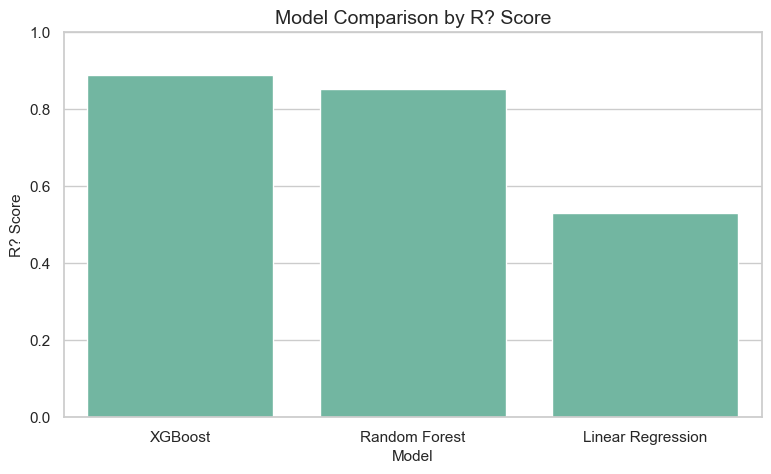

Insight: The best model should have high R? and low MAE/RMSE, meaning it explains fare variation while keeping prediction errors small.


In [41]:
plt.figure(figsize=(9, 5))
sns.barplot(data=evaluation_df, x="Model", y="R2")
plt.title("Model Comparison by R? Score")
plt.xlabel("Model")
plt.ylabel("R? Score")
plt.ylim(0, 1)
plt.show()

print("Insight: The best model should have high R? and low MAE/RMSE, meaning it explains fare variation while keeping prediction errors small.")

### Cross-Validation R² Score and MAE Comparison – All Models

A single train-test split can vary depending on which rows enter the test set. To check model stability, I also compare all models using 5-fold cross-validation. R² is better when higher, while MAE is better when lower.


,Model,CV R2 Mean,CV R2 Std,CV MAE Mean,CV MAE Std
0,XGBoost,0.8903,0.0264,₹693.05,₹44.79
1,Random Forest,0.8510,0.0369,₹867.60,₹39.42
2,Linear Regression,0.5287,0.0375,"₹2,192.29",₹52.80


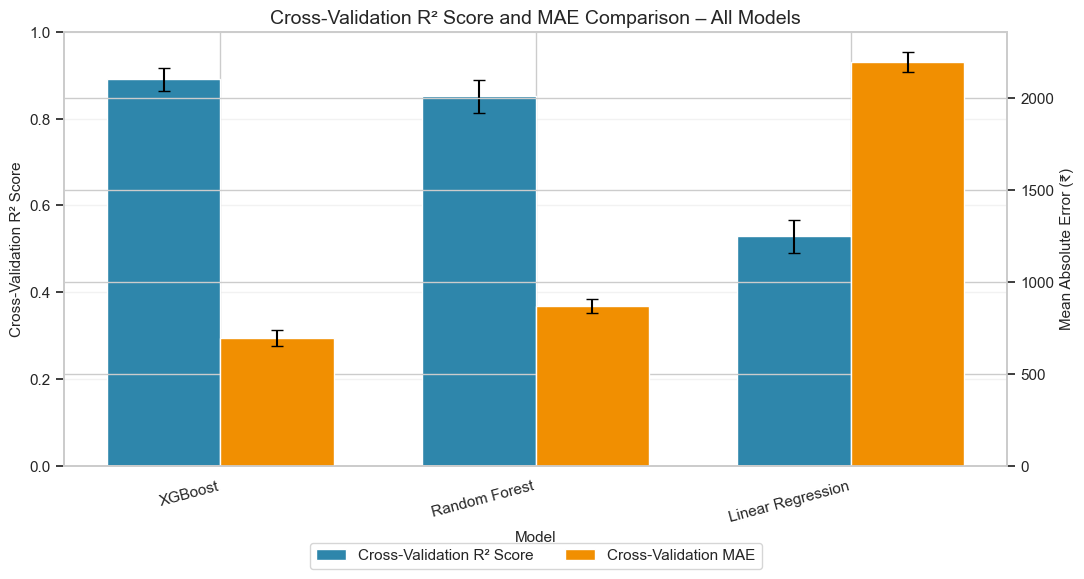

Insight: The strongest model should keep a high average cross-validation R? while also producing a low average MAE across folds.


In [42]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_rows = []
for model_name, model in models.items():
    cv_pipeline = preprocess.build_training_pipeline(metadata, model)
    cv_scores = cross_validate(
        cv_pipeline,
        X,
        y,
        cv=cv,
        scoring={"R2": "r2", "MAE": "neg_mean_absolute_error"},
        n_jobs=1
    )

    cv_rows.append({
        "Model": model_name,
        "CV R2 Mean": cv_scores["test_R2"].mean(),
        "CV R2 Std": cv_scores["test_R2"].std(),
        "CV MAE Mean": -cv_scores["test_MAE"].mean(),
        "CV MAE Std": cv_scores["test_MAE"].std()
    })

cv_results_df = pd.DataFrame(cv_rows).sort_values(
    by="CV R2 Mean", ascending=False
).reset_index(drop=True)

display(cv_results_df.style.format({
    "CV R2 Mean": "{:.4f}",
    "CV R2 Std": "{:.4f}",
    "CV MAE Mean": "₹{:,.2f}",
    "CV MAE Std": "₹{:,.2f}"
}))

x = np.arange(len(cv_results_df))
width = 0.36

fig, ax_r2 = plt.subplots(figsize=(11, 6))
bars_r2 = ax_r2.bar(
    x - width / 2,
    cv_results_df["CV R2 Mean"],
    width,
    yerr=cv_results_df["CV R2 Std"],
    capsize=4,
    label="Cross-Validation R² Score",
    color="#2E86AB"
)
ax_r2.set_ylabel("Cross-Validation R² Score")
ax_r2.set_ylim(0, max(1.0, cv_results_df["CV R2 Mean"].max() + 0.1))
ax_r2.set_xticks(x)
ax_r2.set_xticklabels(cv_results_df["Model"], rotation=15, ha="right")

ax_mae = ax_r2.twinx()
bars_mae = ax_mae.bar(
    x + width / 2,
    cv_results_df["CV MAE Mean"],
    width,
    yerr=cv_results_df["CV MAE Std"],
    capsize=4,
    label="Cross-Validation MAE",
    color="#F18F01"
)
ax_mae.set_ylabel("Mean Absolute Error (₹)")

ax_r2.set_title("Cross-Validation R² Score and MAE Comparison – All Models")
ax_r2.set_xlabel("Model")
ax_r2.grid(axis="y", alpha=0.25)

handles = [bars_r2, bars_mae]
labels = [handle.get_label() for handle in handles]
ax_r2.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=2)

plt.tight_layout()
plt.show()

print("Insight: The strongest model should keep a high average cross-validation R? while also producing a low average MAE across folds.")

## 10. Best Model Selection

The best model is selected based on the highest R? score, while also checking MAE and RMSE. A high R? means the model captures the overall pricing pattern well. Lower MAE and RMSE mean the model makes smaller fare errors.

From a bias-variance point of view:

- Linear Regression has higher bias because it assumes a mostly linear relationship.
- Random Forest reduces bias by learning non-linear patterns, but may become complex.
- XGBoost often performs well because it builds boosted trees sequentially and corrects previous errors.

The final choice should balance accuracy and generalisation.

In [43]:
best_model_name = evaluation_df.loc[0, "Model"]
best_pipeline = trained_models[best_model_name]

print("Best model selected:", best_model_name)
print("\nBest model metrics:")
print(evaluation_df.loc[0])

Best model selected: XGBoost

Best model metrics:
Model        XGBoost
R2          0.890067
MAE       690.656537
RMSE     1525.327229
Name: 0, dtype: object


### Fig 9.5.1 Residual Plot – Predicted vs. Actual Fare on Hold-out Set

This figure checks how prediction errors behave on the hold-out test set. Residuals are calculated as actual fare minus predicted fare. Points should be scattered around the zero line without a strong pattern.


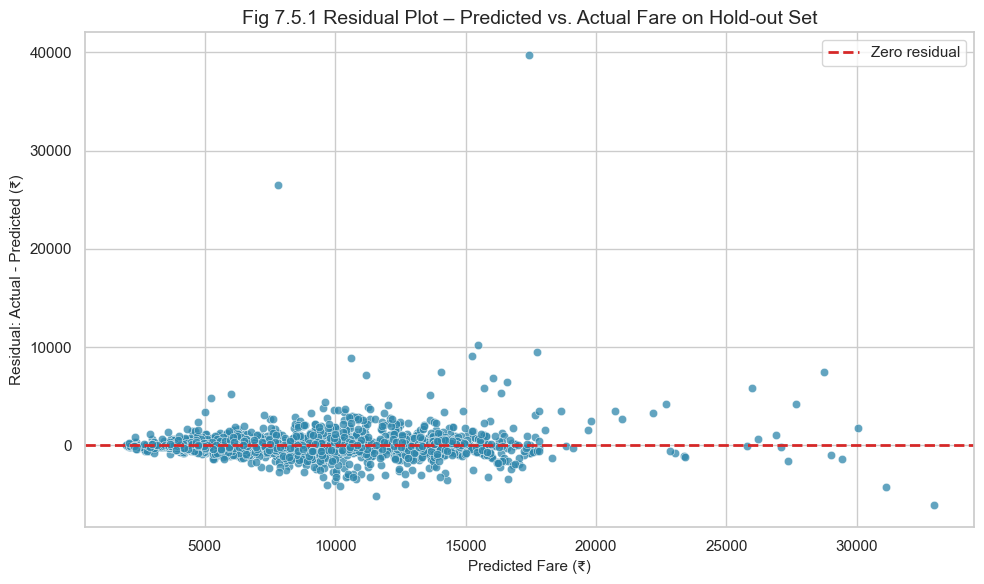

Insight: Residuals centered near zero indicate balanced predictions. A visible curve or funnel shape would suggest systematic error or changing variance.


In [44]:
if "best_pipeline" not in globals():
    best_model_name = evaluation_df.loc[0, "Model"]
    best_pipeline = trained_models[best_model_name]
    print("Best pipeline restored from trained_models:", best_model_name)

holdout_predictions = best_pipeline.predict(X_test)
holdout_residuals = y_test - holdout_predictions

residual_df = pd.DataFrame({
    "Actual Fare": y_test.values,
    "Predicted Fare": holdout_predictions,
    "Residual": holdout_residuals.values
})

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=residual_df,
    x="Predicted Fare",
    y="Residual",
    color="#2E86AB",
    alpha=0.75,
    edgecolor="white",
    linewidth=0.4
)
plt.axhline(0, color="#D62828", linestyle="--", linewidth=2, label="Zero residual")
plt.title("Fig 9.5.1 Residual Plot – Predicted vs. Actual Fare on Hold-out Set")
plt.xlabel("Predicted Fare (₹)")
plt.ylabel("Residual: Actual - Predicted (₹)")
plt.legend()
plt.tight_layout()
plt.show()

print("Insight: Residuals centered near zero indicate balanced predictions. A visible curve or funnel shape would suggest systematic error or changing variance.")


### Cross-check with Production Training Function

The notebook training above is written transparently for academic explanation. The project also contains a reusable production function, `train.train_model()`, which performs the same overall training workflow and returns the best model report.

I run it with `save_model=False` here so the notebook demonstrates integration without overwriting saved production artefacts.

In [45]:
production_report = train.train_model(df_clean, save_model=False)

print("Production training best model:", production_report["best_model"])
print("Production training metrics:", production_report["metrics"])

Price column detected: 'Price'
Datatype after cleaning: int64
Null values after cleaning: 0
First 5 cleaned price values: [3897, 7662, 13882, 6218, 13302]
Production training best model: XGBoost
Production training metrics: {'r2': 0.8929593441942034, 'mae': 672.2425124686513, 'rmse': 1505.1261761233218}


## 11. Prediction Demo

In this section, I use the best trained pipeline to predict fares for sample records. The sample records are taken from the existing feature table so that the prediction demo is focused on model behaviour rather than manual input formatting.

The predicted values are formatted using `utils.format_predictions()`.

In [46]:
if "best_pipeline" not in globals():
    best_model_name = evaluation_df.loc[0, "Model"]
    best_pipeline = trained_models[best_model_name]
    print("Best pipeline restored from trained_models:", best_model_name)

sample_X = X_test.head(5).copy()
sample_actual = y_test.head(5).reset_index(drop=True)

sample_predictions = best_pipeline.predict(sample_X)
formatted_predictions = utils.format_predictions(sample_predictions, currency="?")

visible_cols = [
    "Airline", "Source", "Destination", "Duration_minutes",
    "Total_Stops", "Distance_km", "days_left"
]
prediction_demo = sample_X[[col for col in visible_cols if col in sample_X.columns]].copy()
prediction_demo["Actual Price"] = utils.format_predictions(sample_actual.values, currency="?")
prediction_demo["Predicted Price"] = formatted_predictions

prediction_demo

,Airline,Source,Destination,Duration_minutes,Total_Stops,Distance_km,days_left,Actual Price,Predicted Price
6076,Jet Airways,Kolkata,Banglore,750,1,1560.696623,0,"?10,844","?10,605"
3544,GoAir,Delhi,Cochin,540,1,2079.743081,0,"?4,959","?5,738"
7313,Jet Airways,Kolkata,Banglore,345,1,1560.696623,0,"?14,781","?15,114"
5032,IndiGo,Chennai,Kolkata,140,0,1358.360715,0,"?3,858","?3,811"
2483,Jet Airways,Delhi,Cochin,335,1,2079.743081,0,"?12,898","?12,584"


## 12. Real-World Dynamic Pricing Simulation

In real airline systems, the displayed fare may change even after a base model predicts a price. This is because live demand, seat availability, booking window, and seasonal trends can affect the final fare.

My project includes `utils.get_live_price()` to simulate this idea. It starts with the model's base prediction and adjusts it using:

- `days_left`: how close the journey is
- `trend_factor`: year-based fare movement
- `demand_factor`: simulated demand pressure

In [47]:
base_price = float(sample_predictions[0])
sample_days_left = int(sample_X["days_left"].iloc[0]) if "days_left" in sample_X.columns else 10
sample_trend_factor = float(sample_X["trend_factor"].iloc[0]) if "trend_factor" in sample_X.columns else 1.0

live_price_normal = utils.get_live_price(
    base_price=base_price,
    days_left=sample_days_left,
    trend_factor=sample_trend_factor,
    demand_factor=1.00
)

live_price_high_demand = utils.get_live_price(
    base_price=base_price,
    days_left=sample_days_left,
    trend_factor=sample_trend_factor,
    demand_factor=1.25
)

print("Base model prediction:", utils.format_predictions(np.array([base_price]), currency="?")[0])
print("Live price under normal demand:", utils.format_predictions(np.array([live_price_normal]), currency="?")[0])
print("Live price under high demand:", utils.format_predictions(np.array([live_price_high_demand]), currency="?")[0])

Base model prediction: ?10,605
Live price under normal demand: ?13,786
Live price under high demand: ?17,232


## 13. Conclusion

This project demonstrates an end-to-end machine learning system for flight fare prediction. The system starts from raw flight data, cleans the fare column, engineers meaningful travel-related features, builds preprocessing pipelines, trains multiple regression models, evaluates them, and demonstrates prediction and live price simulation.

### Key Findings

- Flight fare depends on multiple factors such as airline, route, duration, stops, departure time, distance, and booking window.
- Feature engineering is essential because raw columns like date, time, duration, and route contain hidden pricing signals.
- Tree-based models such as Random Forest and XGBoost are generally stronger than a simple linear baseline for this type of non-linear pricing problem.
- Pipelines make the system more reliable because the same preprocessing is applied during both training and prediction.

### Limitations

- The model depends on the quality and coverage of the historical dataset.
- Real airline prices also depend on live seat inventory, competitor prices, festivals, cancellations, and demand spikes, which may not be fully present in the dataset.
- The live price function is a simulation, not a direct connection to airline pricing APIs.

### Future Improvements

- Add real-time airline or travel API data.
- Include holiday, festival, and event-based demand features.
- Use cross-validation and hyperparameter tuning for more rigorous evaluation.
- Deploy the trained model as a web application with model monitoring.

Overall, the project shows that thoughtful preprocessing, meaningful feature engineering, and model comparison can produce a practical and explainable flight fare prediction system.